In [1]:
import os
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage
from operator import add as add_messages
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.tools import tool

In [35]:
GOOGLE_API_KEY = "***"
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0, api_key=GOOGLE_API_KEY)

In [5]:
# The Embedding Model - has to also be compatible with the LLM
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001", api_key=GOOGLE_API_KEY
)

In [6]:
pdf_path = "Crypto Report 2025.pdf"

In [7]:
pdf_loader = PyPDFLoader(pdf_path) # This loads the PDF

In [10]:
# read PDF pages
try:
    pages = pdf_loader.load()
    print(f"PDF has been loaded and has {len(pages)} pages")
except Exception as e:
    print(f"Error loading PDF: {e}")
    raise

PDF has been loaded and has 53 pages


In [11]:
# Chunking Process
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=50
)

In [12]:
pages_split = text_splitter.split_documents(pages) # We now apply this to our pages

In [20]:
pages_split = pages_split[:10]

In [21]:
persist_directory = r"."
collection_name = "Crypto"

In [23]:
# If our collection does not exist in the directory, we create it
if not os.path.exists(persist_directory):
    os.makedirs(persist_directory)

In [24]:
try:
    # Creating the chroma database using embeddign model
    vectorstore = Chroma.from_documents(
        documents=pages_split,
        embedding=embeddings,
        persist_directory=persist_directory,
        collection_name=collection_name
    )
    print(f"Created ChromaDB vector store!")
    
except Exception as e:
    print(f"Error setting up ChromaDB: {str(e)}")
    raise

Created ChromaDB vector store!


In [25]:
# Now we create the retriever 
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5} # K is the amount of chunks to return
)

In [34]:
@tool
def retriever_tool(query: str) -> str:
    """
    This tool searches and returns the information from the Crypto Performance 2025 document.
    """

    docs = retriever.invoke(query)

    if not docs:
        return "I found no relevant information in the Crypto Performance 2025 document."
    
    results = []
    for i, doc in enumerate(docs):
        results.append(f"Document {i+1}:\n{doc.page_content}")
    
    return "\n\n".join(results)

In [36]:
tools = [retriever_tool]

llm = llm.bind_tools(tools)

In [37]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [38]:
def should_continue(state: AgentState):
    """Check if the last message contains tool calls."""
    result = state['messages'][-1]
    return hasattr(result, 'tool_calls') and len(result.tool_calls) > 0

In [39]:
system_prompt = """
You are an intelligent AI assistant who answers questions about Crypto Performance in 2025 based on the PDF document loaded into your knowledge base.
Use the retriever tool available to answer questions about the performance data. You can make multiple calls if needed.
If you need to look up some information before asking a follow up question, you are allowed to do that!
Always cite the specific parts of the documents you use in your answers.
"""

In [40]:
tools_dict = {tool.name: tool for tool in tools} # Creating a dictionary of tools

In [41]:
tools_dict

{'retriever_tool': StructuredTool(name='retriever_tool', description='This tool searches and returns the information from the Crypto Performance 2025 document.', args_schema=<class 'langchain_core.utils.pydantic.retriever_tool'>, func=<function retriever_tool at 0x000002495DB8D6C0>)}

In [42]:
# LLM Agent
def call_llm(state: AgentState) -> AgentState:
    """Function to call the LLM with the current state."""
    messages = list(state['messages'])
    messages = [SystemMessage(content=system_prompt)] + messages
    message = llm.invoke(messages)
    return {'messages': [message]}

In [43]:
# Retriever Agent
def take_action(state: AgentState) -> AgentState:
    """Execute tool calls from the LLM's response."""

    tool_calls = state['messages'][-1].tool_calls
    results = []
    for t in tool_calls:
        print(f"Calling Tool: {t['name']} with query: {t['args'].get('query', 'No query provided')}")
        
        if not t['name'] in tools_dict: # Checks if a valid tool is present
            print(f"\nTool: {t['name']} does not exist.")
            result = "Incorrect Tool Name, Please Retry and Select tool from List of Available tools."
        
        else:
            result = tools_dict[t['name']].invoke(t['args'].get('query', ''))
            print(f"Result length: {len(str(result))}")
            

        # Appends the Tool Message
        results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))

    print("Tools Execution Complete. Back to the model!")
    return {'messages': results}

In [44]:
graph = StateGraph(AgentState)
graph.add_node("llm", call_llm)
graph.add_node("retriever_agent", take_action)

graph.add_conditional_edges(
    "llm",
    should_continue,
    {True: "retriever_agent", False: END}
)
graph.add_edge("retriever_agent", "llm")
graph.set_entry_point("llm")

rag_agent = graph.compile()

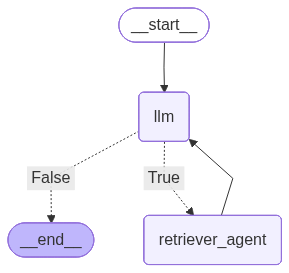

In [45]:
rag_agent

In [52]:
def running_agent():
    print("\n=== RAG AGENT===")
    
    while True:
        user_input = input("\nWhat is your question: ")
        if user_input.lower() in ['exit', 'quit']:
            break
            
        messages = [HumanMessage(content=user_input)] # converts back to a HumanMessage type

        result = rag_agent.invoke({"messages": messages})
        
        print("\n=== ANSWER ===")
        print(result['messages'][-1].content[0]['text'])

In [53]:
running_agent()


=== RAG AGENT===



What is your question:  Which cryptos performed well?


Calling Tool: retriever_tool with query: Which cryptos performed well?
Result length: 1504
Tools Execution Complete. Back to the model!

=== ANSWER ===
Based on the 2025 Q3 Crypto Industry Report:

*   **USDe** saw a massive surge, climbing from #26 to #12 (Document 2).
*   New entrants to the Top 30 included **FIGR_HELOC** (#13), **USDT0** (#24), **CRO** (#26), and **MNT** (#27) (Document 2).

Conversely, **PEPE, AAVE, UNI, and BGB** all fell out of the Top 30 (Document 2).



What is your question:  Give me a quick summary of total crypto market cap.


Calling Tool: retriever_tool with query: total crypto market cap summary
Result length: 1824
Tools Execution Complete. Back to the model!

=== ANSWER ===
The total crypto market cap maintained an upward trajectory, increasing by +$563.6B (+16.4%) to close Q3 2025 at $4.0T. This marks the second consecutive quarter of significant capital appreciation. (Source: Document 1, Document 2)



What is your question:  who is Yung Kai?


Calling Tool: retriever_tool with query: Yung Kai
Result length: 1401
Tools Execution Complete. Back to the model!

=== ANSWER ===
I am sorry, but I couldn't find any information about "Yung Kai" in the provided "Crypto Performance 2025" document. The document mentions other individuals such as Choon Khei, Weng Dee, and Shaun Lee as Market Analysts, and Zhong as Head of Research.



What is your question:  exit
